<a href="https://colab.research.google.com/github/Darshan-12345/Deep-Learning-/blob/main/Assignments/assignment_NO_4_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0177 - val_loss: 0.0099
Epoch 2/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0117 - val_loss: 0.0098
Epoch 3/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0113 - val_loss: 0.0094
Epoch 4/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0109 - val_loss: 0.0093
Epoch 5/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0106 - val_loss: 0.0094
Epoch 6/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0103 - val_loss: 0.0090
Epoch 7/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0103 - val_loss: 0.0104
Epoch 8/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0098 - val_loss: 0.0091
Epoch 9/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0094 - val_loss: 0.0105
Epoch 10/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0096 - val_loss: 0.0084
Epoch 11/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0093 - val_loss: 0.0084
Epoch 12/100
155/155 ━━━━━━━━━━━━━━━

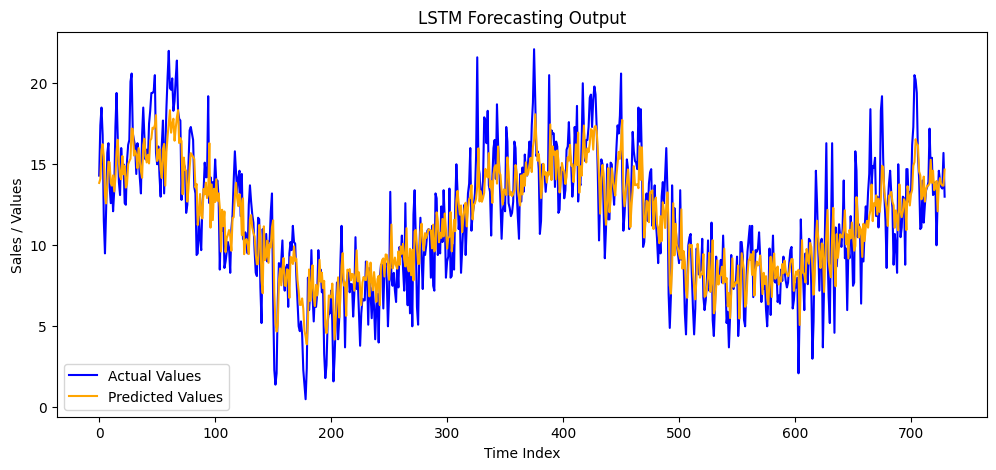

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# 1. Load Daily Dataset (Verified Working Raw URL)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

df = pd.read_csv(url)
df.columns = ['Date', 'Sales']
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# 2. Add Cyclical Date Features
df['Month'] = df['Date'].dt.month
df['Sin_Month'] = np.sin(2 * np.pi * df['Month'] / 12.0)
df['Cos_Month'] = np.cos(2 * np.pi * df['Month'] / 12.0)

target_col = ['Sales']
feature_cols = ['Sin_Month', 'Cos_Month']

# 3. Train/Test Split (80/20)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# 4. Independent Scaling (Prevents Data Leakage)
scaler_y = MinMaxScaler()
scaler_X = MinMaxScaler()

train_y = scaler_y.fit_transform(train_df[target_col])
test_y = scaler_y.transform(test_df[target_col])

train_X = scaler_X.fit_transform(train_df[feature_cols])
test_X = scaler_X.transform(test_df[feature_cols])

train_scaled = np.hstack([train_y, train_X])
test_scaled = np.hstack([test_y, test_X])

# 5. Sequence Generator (12 Time Steps Lookback)
def create_sequences(data, time_steps=12):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i - time_steps:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_steps = 12
X_train, y_train = create_sequences(train_scaled, time_steps)

# Overlap training tail so test evaluation preserves all test dates
full_test_data = np.vstack([train_scaled[-time_steps:], test_scaled])
X_test, y_test = create_sequences(full_test_data, time_steps)

# 6. Build LSTM Network
n_features = train_scaled.shape[1]

model = Sequential([
    Input(shape=(time_steps, n_features)),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# 7. Train Model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

# 8. Evaluate & Inverse Transform
raw_preds = model.predict(X_test)
predictions = scaler_y.inverse_transform(raw_preds).flatten()
actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Metrics
mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))
r2 = r2_score(actual, predictions)

print(f"\n--- Evaluation Metrics ---")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# 9. Plot Results
plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual Values', color='blue')
plt.plot(predictions, label='Predicted Values', color='orange')
plt.xlabel("Time Index")
plt.ylabel("Sales / Values")
plt.title("LSTM Forecasting Output")
plt.legend()
plt.show()